# Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodríguez Teodores Armando Jair
* Velasco Martell Dayra

# Bibliotecas

In [1]:
#Bibliotecas
import os
import pandas as pd
import numpy as np

#KS test, ji-cuadrada
from scipy.stats import ks_2samp, chi2_contingency

#Graficas
import matplotlib.pyplot as plt
from matplotlib import cycler
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Valores atipicos
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.mcd import MCD

#Valores ausentes
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
# Configurar Paleta
PALETA = sns.color_palette("flare")
sns.set_theme(style="whitegrid", palette=PALETA)   # Seaborn global
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.prop_cycle"] = cycler(color=PALETA.as_hex())  # Matplotlib global

# Cargar Dataset

In [3]:
def ruta(folder, file, user='Wsm-erick', main='Diplomado-Ciencia-de-Datos/refs/heads/main'):
    return os.path.join('https://raw.githubusercontent.com', user, main, folder, file)

In [4]:
url = ruta('Modulo-I/Datasets', 'wine_quality.csv')

df = pd.read_csv(url, encoding='utf-8')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,red
3,NaN,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,NaN
4,7.4,0.70,NaN,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red


## 1.- Investiga a qué se refiere cada variable del conjunto de datos y sus valores normales de referencia.

Se encontró la siguiente informacion referente a los valores normales para cada una de las variables. Con base en esta informacion, se tomara la decision sobre el tratado de los valores atipicos que se lleguen a encontrar en la base.

In [5]:
url = ruta('Modulo-I/Datasets', 'Variables_del_vino.csv')

description = pd.read_csv(url, encoding='utf-8')
description

,Variable,Valor normal / típico,Descripción breve
0,fixed acidity,4.0 – 15.0 g/dm³ (tinto más ácido que blanco),Ácidos no volátiles como tartárico
1,volatile acidity,0.12 – 1.10 g/dm³,Ácidos volátiles (como el acético)
2,citric acid,0.0 – 1.0 g/dm³,Contribuye a frescura
3,residual sugar,0.6 – 65.0 g/dm³ (más en vinos blancos),Azúcar restante tras fermentación
4,chlorides,0.009 – 0.346 g/dm³,Indica presencia de sal
5,free sulfur dioxide,1 – 72 mg/dm³ (mayor en blancos),"SO₂ libre, protección antimicrobiana"
6,total sulfur dioxide,6 – 440 mg/dm³ (mayor en blancos),Total de SO₂ (libre + ligado)
7,density,0.9900 – 1.0040 g/cm³,Relacionado con azúcar y alcohol
8,pH,2.9 – 3.9,"Acidez, vinos blancos suelen tener pH más bajo"
9,sulphates,0.22 – 1.08 g/dm³,Estabilizador y conservante


In [6]:
valores_tipicos = {x: None for x in set(description['Variable'])-set({'type'})}

print(list(valores_tipicos.keys()))

['residual sugar', 'alcohol', 'citric acid', 'chlorides', 'fixed acidity', 'total sulfur dioxide', 'sulphates', 'density', 'free sulfur dioxide', 'pH', 'volatile acidity', 'quality']


In [7]:
valores_tipicos = {
    'fixed acidity': (4,15,'g/dm³'),
    'volatile acidity': (0.12,1.1,'g/dm³'),
    'citric acid': (0,1,'g/dm³'),
    'residual sugar': (0.6,65,'g/dm³'),
    'chlorides': (0.009,0.346,'g/dm³'),
    'free sulfur dioxide': (1,72,'mg/dm³'),
    'total sulfur dioxide': (6,440,'mg/dm³'),
    'density': (0.99,1.0040,'g/cm³'),
    'pH': (2.9,3.9,'-'),
    'sulphates': (0.22,1.08,'g/dm³'),
    'alcohol': (8,14.9,'vol'),
    'quality': (3,9,'-')
}

In [8]:
def f_tip(x: float, xmin: float, xmax: float):
  return 1 if x >= xmin and x <= xmax else 0

N = df.shape[0]
data = []
for x, (xmin, xmax, unidad) in valores_tipicos.items():
  n = df[x].apply(lambda y: f_tip(y, xmin, xmax)).sum()
  nulos = df[x].isna().sum()
  data.append([x, unidad, xmin, xmax, nulos, n, N-n-nulos])

df_val_atipicos = pd.DataFrame(data=data, columns=['Variable', 'Unidad', 'Límite Inf', 'Límite Sup', 'Valores Ausentes', 'Valores Típicos', 'Valores Atípicos'])
display(df_val_atipicos)

,Variable,Unidad,Límite Inf,Límite Sup,Valores Ausentes,Valores Típicos,Valores Atípicos
0,fixed acidity,g/dm³,4.000,15.000,995,5497,5
1,volatile acidity,g/dm³,0.120,1.100,949,5517,31
2,citric acid,g/dm³,0.000,1.000,454,6042,1
3,residual sugar,g/dm³,0.600,65.000,200,6296,1
4,chlorides,g/dm³,0.009,0.346,0,6479,18
5,free sulfur dioxide,mg/dm³,1.000,72.000,138,6267,92
6,total sulfur dioxide,mg/dm³,6.000,440.000,744,5753,0
7,density,g/cm³,0.990,1.004,0,6149,348
8,pH,-,2.900,3.900,180,6238,79
9,sulphates,g/dm³,0.220,1.080,626,5836,35


In [9]:
print("Valores atípicos con respecto a los valores normales de la variable:", df_val_atipicos['Valores Atípicos'].sum())

Valores atípicos con respecto a los valores normales de la variable: 610


## 2.- ¿Existen valores atípicos? ¿Valores ausentes?

Sí, como vemos en las celdas anteriores si hay valores ausentes y valores atípicos. A continuación vamos a revisar más a detalle los valores ausentes e imputaremos por el método de MICE los valores nulos para poder revisar los valores atípicos, cuando el dataset no contenga valores nulos.

In [10]:
var_cat = ["type"]
var_num = list(set(df.columns) - set(var_cat))

In [11]:
print('Variables categóricas:', var_cat[0],
    '\n\n'+'Variables numéricas:', ', '.join(var_num))

Variables categóricas: type 

Variables numéricas: residual sugar, alcohol, citric acid, chlorides, fixed acidity, total sulfur dioxide, sulphates, density, free sulfur dioxide, pH, volatile acidity, quality


In [12]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    #Creamos la tabla
    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [13]:
is_na_df(df)

,columna,n_missing,total,prop_missing,prop_original
0,fixed acidity,995,6497,0.153148,0.846852
1,volatile acidity,949,6497,0.146067,0.853933
2,citric acid,454,6497,0.069878,0.930122
3,residual sugar,200,6497,0.030783,0.969217
4,free sulfur dioxide,138,6497,0.021241,0.978759
5,total sulfur dioxide,744,6497,0.114514,0.885486
6,pH,180,6497,0.027705,0.972295
7,sulphates,626,6497,0.096352,0.903648
8,alcohol,183,6497,0.028167,0.971833
9,quality,591,6497,0.090965,0.909035


Obtenemos que 10 variables cuentan con valores ausentes. Se representa en la siguiente tabla el numero de valores ausentes por variable y la proporcion que representan.

Realizaremos dos metodos de imputacion con el fin de poder determinar cual es el mas conveniente en cuanto a la preservacion de las distribuciones.

### Imputación en cadena (MICE)

In [14]:
def evaluate_imputation(df_original, df_imputed, vars_num=None, vars_cat=None):
    resultados = []

    # KS test en variables numéricas
    if vars_num:
        for col in vars_num:
            orig = df_original[col].dropna()
            imp = df_imputed[col]
            stat, pval = ks_2samp(orig, imp)
            resultados.append({
                "Variable": col,
                "Tipo": "Numérica",
                "Prueba": "KS test",
                "Estadístico": stat,
                "p-value": pval
            })

    # Chi-cuadrada en variables categóricas
    if vars_cat:
        for col in vars_cat:
            orig_counts = df_original[col].value_counts(dropna=True, normalize=True)
            imp_counts = df_imputed[col].value_counts(normalize=True)

            categories = list(set(orig_counts.index) | set(imp_counts.index))
            observed = np.array([
                [orig_counts.get(cat, 0), imp_counts.get(cat, 0)]
                for cat in categories
            ])
            chi2, pval, _, _ = chi2_contingency(observed.T)
            resultados.append({
                "Variable": col,
                "Tipo": "Categórica",
                "Prueba": "Chi-cuadrada",
                "Estadístico": chi2,
                "p-value": pval
            })

    return pd.DataFrame(resultados)

In [15]:
def impute_mice(df, vars_num, vars_cat, random_state=1989, max_iter=1000):
    df_copy = df.copy()

    # Convertir categóricas a códigos numéricos temporales
    cat_maps = {}
    for col in vars_cat:
        df_copy[col] = df_copy[col].astype("category")
        cat_maps[col] = dict(enumerate(df_copy[col].cat.categories))
        df_copy[col] = df_copy[col].cat.codes.replace(-1, np.nan)

    # IterativeImputer trabaja sobre todo el DF
    imputer = IterativeImputer(random_state=random_state, max_iter=max_iter)
    imputed_array = imputer.fit_transform(df_copy)
    imputed_df = pd.DataFrame(imputed_array, columns=df_copy.columns, index=df_copy.index)

    # Redondear categóricas y devolver a etiquetas originales
    for col in vars_cat:
        imputed_df[col] = imputed_df[col].round().astype(int)
        imputed_df[col] = imputed_df[col].map(cat_maps[col])

    reporte = evaluate_imputation(df, imputed_df, vars_num, vars_cat)
    return imputed_df, reporte

In [16]:
micer = impute_mice(df, var_num, var_cat)

In [17]:
display(micer[0], micer[1])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.400000,0.700000,0.000000,1.900000,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.000000,red
1,7.800000,0.880000,0.000000,2.600000,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5.000000,red
2,7.800000,0.760000,0.040000,2.300000,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5.000000,red
3,10.178140,0.280000,0.560000,1.900000,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6.000000,red
4,7.400000,0.700000,0.117625,1.900000,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.000000,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.371783,0.210000,0.290000,1.600000,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.000000,white
6493,6.500478,0.320000,0.360000,8.000000,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.000000,white
6494,6.500000,0.240000,0.190000,3.349322,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,5.485587,white
6495,5.500000,0.290672,0.300000,1.100000,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.000000,white


,Variable,Tipo,Prueba,Estadístico,p-value
0,residual sugar,Numérica,KS test,0.004566,1.000000
1,alcohol,Numérica,KS test,0.002589,1.000000
2,citric acid,Numérica,KS test,0.007881,0.988915
3,chlorides,Numérica,KS test,0.000000,1.000000
4,fixed acidity,Numérica,KS test,0.016022,0.423044
5,total sulfur dioxide,Numérica,KS test,0.010920,0.854591
6,sulphates,Numérica,KS test,0.021906,0.101626
7,density,Numérica,KS test,0.000000,1.000000
8,free sulfur dioxide,Numérica,KS test,0.001406,1.000000
9,pH,Numérica,KS test,0.004205,1.000000


Realizando la prueba de KS obtenemos que la mayoría de las variables tienen un p-value mayor que 0.05 a excepecion de una, la variable quality. De igual manera, con este metodo de imputacion ya no presentamos ningun valor ausente.

Sin embargo, debido a que una variable no paso la prueba de KS, realizaremos otro metodo de imputacion con el fin de poder ver cual de los dos nos arroja mejores resultados.

In [18]:
is_na_df(micer[1])

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,65,0.0,1.0


In [19]:
imputed_df = micer[0]

In [20]:
imputed_df.describe(include = "all")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6494
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4897
mean,7.215580,0.340131,0.318424,5.443155,0.056034,30.528763,115.376127,0.994697,3.218443,0.531498,10.494635,5.816498,NaN
std,1.272535,0.158513,0.141323,4.749903,0.035034,17.639884,55.591614,0.002999,0.160206,0.145053,1.188895,0.844550,NaN
min,3.800000,-0.261265,-0.282880,-3.297837,0.009000,-0.813248,-19.857417,0.987110,2.720000,0.220000,8.000000,3.000000,NaN
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,78.000000,0.992340,3.110000,0.440000,9.500000,5.000000,NaN
50%,7.000000,0.295000,0.310000,3.100000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,NaN
75%,7.700000,0.410000,0.390000,8.100000,0.065000,41.000000,154.108606,0.996990,3.320000,0.600000,11.300000,6.000000,NaN


### Imputación Random Forest

In [21]:
#Metodo de Random Forest

def impute_rf(df, vars_num, vars_cat, random_state=1989, max_iter=10):
    df_copy = df.copy()

    # Convertir variables categóricas a códigos numéricos temporales
    cat_maps = {}
    for col in vars_cat:
        df_copy[col] = df_copy[col].astype("category")
        cat_maps[col] = dict(enumerate(df_copy[col].cat.categories))
        df_copy[col] = df_copy[col].cat.codes.replace(-1, np.nan)

    # Imputar con IterativeImputer + RandomForestRegressor
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=100, random_state=random_state),
        random_state=random_state,
        max_iter=max_iter
    )

    imputed_array = imputer.fit_transform(df_copy)
    imputed_df = pd.DataFrame(imputed_array, columns=df_copy.columns, index=df_copy.index)

    # Restaurar variables categóricas
    for col in vars_cat:
        imputed_df[col] = imputed_df[col].round().astype(int)
        imputed_df[col] = imputed_df[col].map(cat_maps[col])

    # Reporte de comparación (suponiendo que tienes una función definida)
    reporte = evaluate_imputation(df, imputed_df, vars_num, vars_cat)
    return imputed_df, reporte

In [22]:
randomforest = impute_rf(df, var_num, var_cat)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [25]:
display(randomforest[0], randomforest[1])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.400,0.70000,0.0000,1.900,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.00,red
1,7.800,0.88000,0.0000,2.600,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5.00,red
2,7.800,0.76000,0.0400,2.300,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5.00,red
3,10.391,0.28000,0.5600,1.900,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6.00,red
4,7.400,0.70000,0.0166,1.900,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.00,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.433,0.21000,0.2900,1.600,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.00,white
6493,6.568,0.32000,0.3600,8.000,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.00,white
6494,6.500,0.24000,0.1900,1.577,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,5.41,white
6495,5.500,0.31310,0.3000,1.100,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.00,white


,Variable,Tipo,Prueba,Estadístico,p-value
0,residual sugar,Numérica,KS test,0.005161,0.999994
1,alcohol,Numérica,KS test,0.002627,1.000000
2,citric acid,Numérica,KS test,0.008958,0.960481
3,chlorides,Numérica,KS test,0.000000,1.000000
4,fixed acidity,Numérica,KS test,0.020821,0.148284
5,total sulfur dioxide,Numérica,KS test,0.006746,0.998890
6,sulphates,Numérica,KS test,0.020673,0.140607
7,density,Numérica,KS test,0.000000,1.000000
8,free sulfur dioxide,Numérica,KS test,0.001588,1.000000
9,pH,Numérica,KS test,0.004182,1.000000


### Diferencias por cada Imputación

In [27]:
mice_aux = micer[1].copy()
randomforest_aux = randomforest[1].copy()

var_order = randomforest_aux['Variable']

randomforest_aux.set_index('Variable', inplace=True)
mice_aux.set_index('Variable', inplace=True)

randomforest_aux = randomforest_aux.filter(['p-value'])
mice_aux = mice_aux.filter(['p-value'])

randomforest_aux.rename(columns={'p-value': 'p-value (randomforest)'}, inplace=True)
mice_aux.rename(columns={'p-value': 'p-value (mice)'}, inplace=True)

merged = pd.merge(
    randomforest_aux, mice_aux,
    left_index=True,
    right_index=True,
    how="inner"
)

In [28]:
merged

,p-value (randomforest),p-value (mice)
Variable,,
residual sugar,0.999994,1.000000
alcohol,1.000000,1.000000
citric acid,0.960481,0.988915
chlorides,1.000000,1.000000
fixed acidity,0.148284,0.423044
total sulfur dioxide,0.998890,0.854591
sulphates,0.140607,0.101626
density,1.000000,1.000000
free sulfur dioxide,1.000000,1.000000


Dados los resultados vemos conveniente considerar la imputación por el método mice, por los resultados que son similares a los de random forest y que algunas variables como fixed acidity mantiene mejor la distribución original y porque computacionalmente es menos demandante.

### Atípicos

In [29]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas (cada una en figura independiente)
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             #marker_color="#00a77d", 
                             #marker_color='#722F37',
                             marker_color="rgba(114, 47, 55, 0.5)",  # burdeos con 50% transparencia
                             nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable numérica: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        n = len(self.cat_vars)
        cols = 2
        rows = (n + 1) // cols if n > 1 else 1

        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type':'domain'}]*cols for _ in range(rows)],
            subplot_titles=self.cat_vars
        )

        for i, var in enumerate(self.cat_vars):
            row = i // cols + 1
            col = i % cols + 1

            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            wine_palette = [
                "#722F37", "#B85042", "#E6AF2E", "#F6D55C", "#F4A7B9",
                "#2F4F4F", "#8D6E63", "#A1887F", "#D7CCC8", "#795548"
            ]
            
            fig.add_trace(
                go.Pie(
                    labels=labels, 
                    values=values, 
                    name=var, 
                    textinfo='percent+label',
                    marker=dict(colors=wine_palette)
                ),
                row=row, col=col
            )

            #fig.add_trace(
            #    go.Pie(labels=labels, values=values, name=var, textinfo='percent+label'),
            #    row=row, col=col
            #)

        fig.update_layout(title_text="Variables Categóricas", height=400*rows)
        fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale=color,
            text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
            texttemplate="%{text}",                # mostrar texto en cada celda
            textfont={"size":10, "color":"black"}  # estilo de fuente
            ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [30]:
analisis = analyze(imputed_df, var_num, var_cat)

Exploración de distribución de cada variable para la detección de valores atípicos (primer acercamiento).

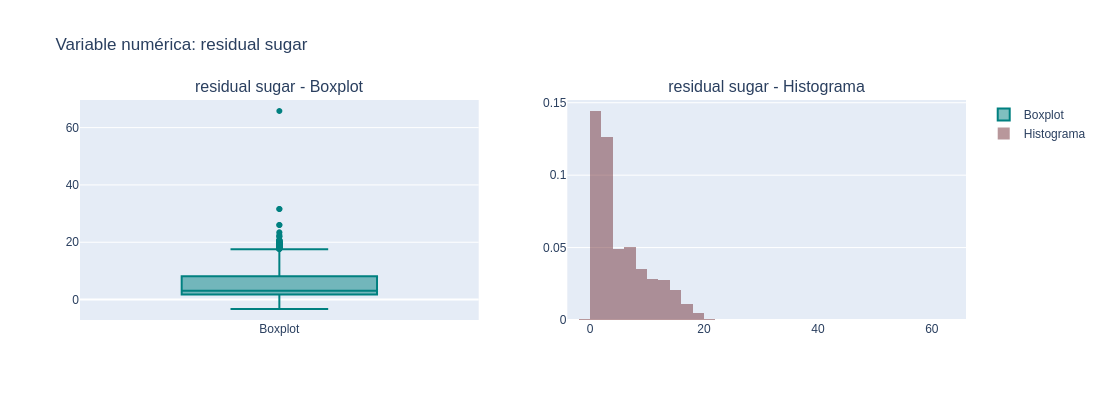

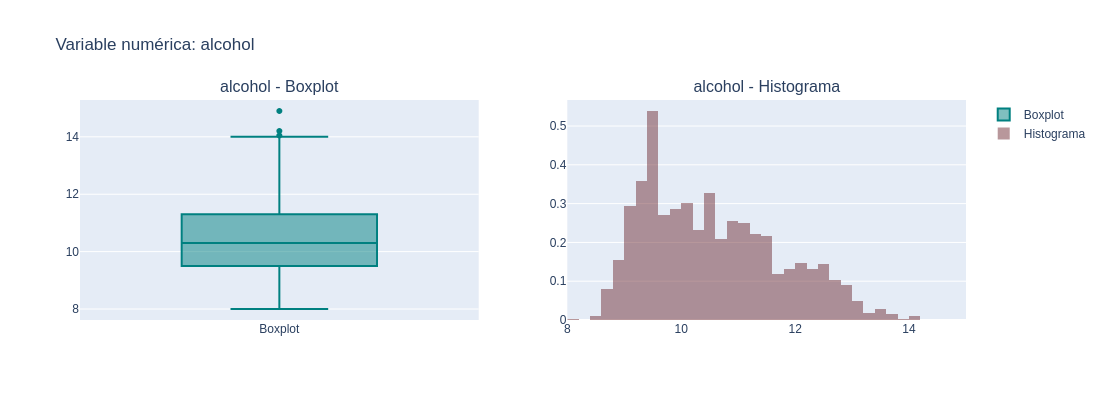

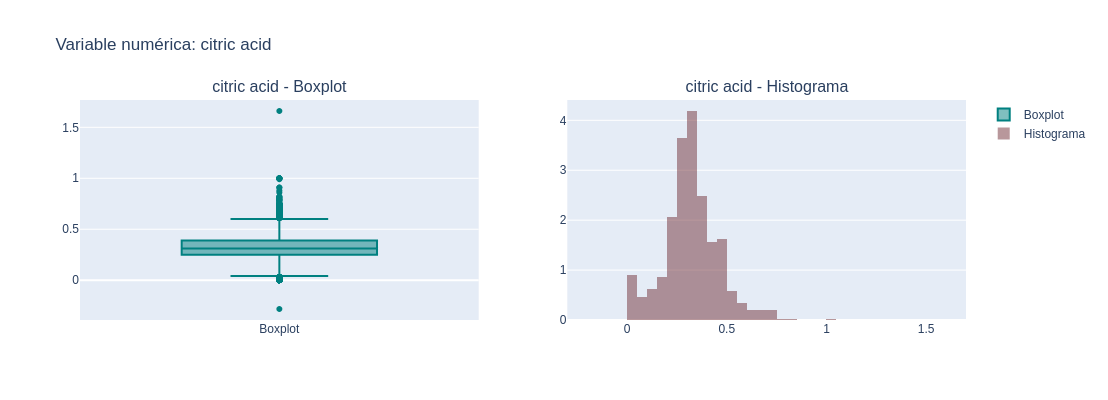

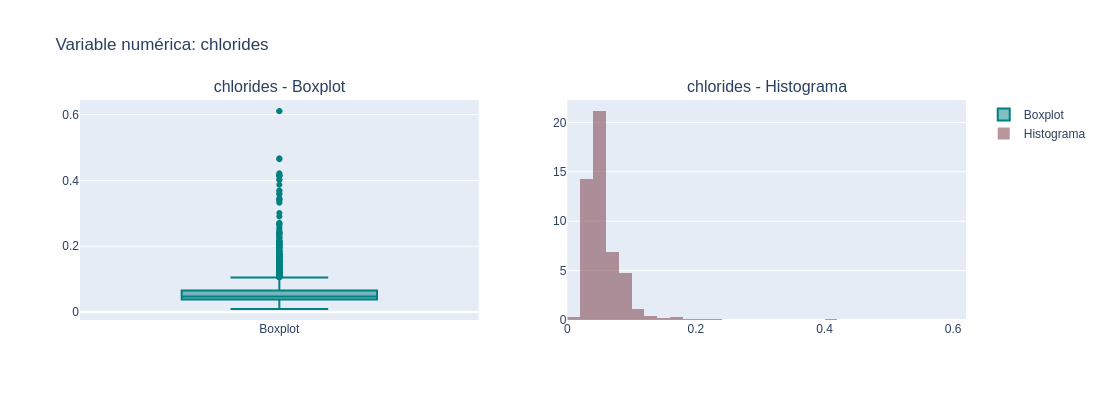

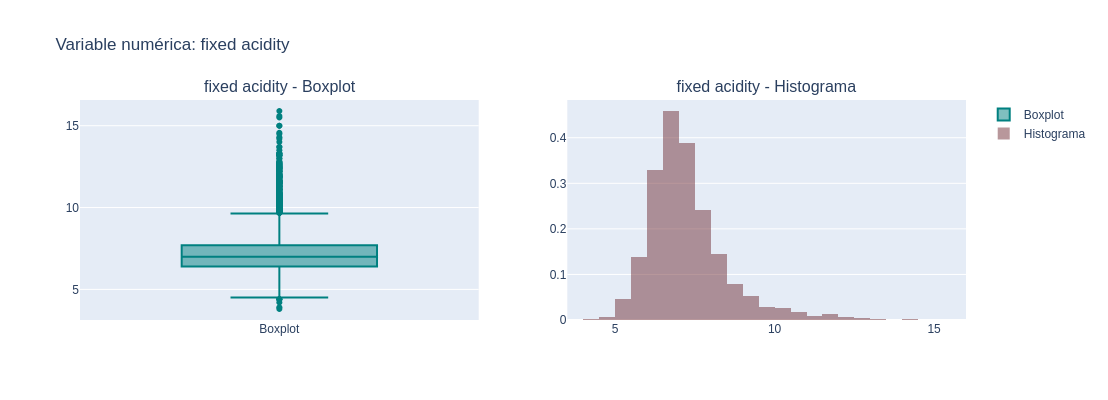

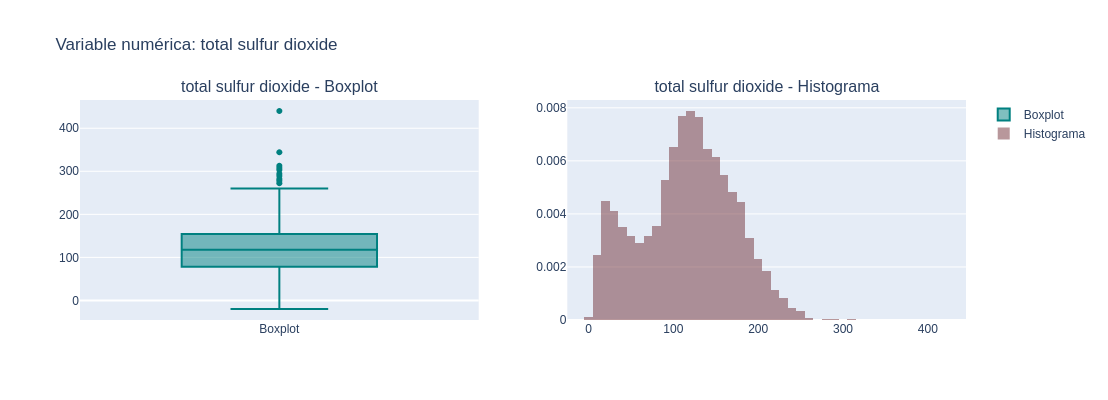

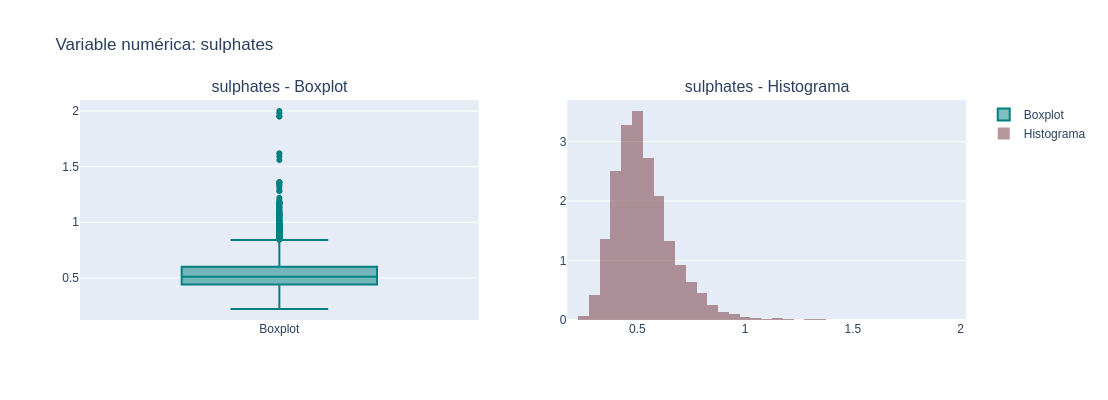

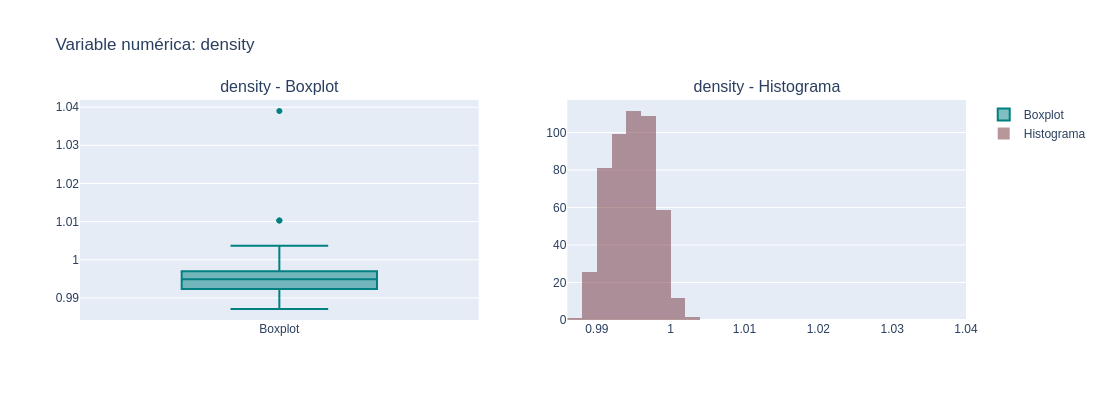

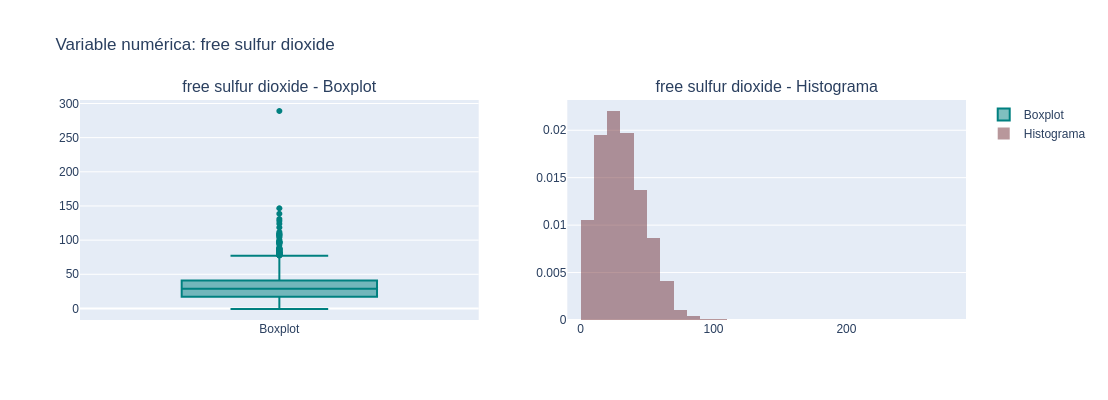

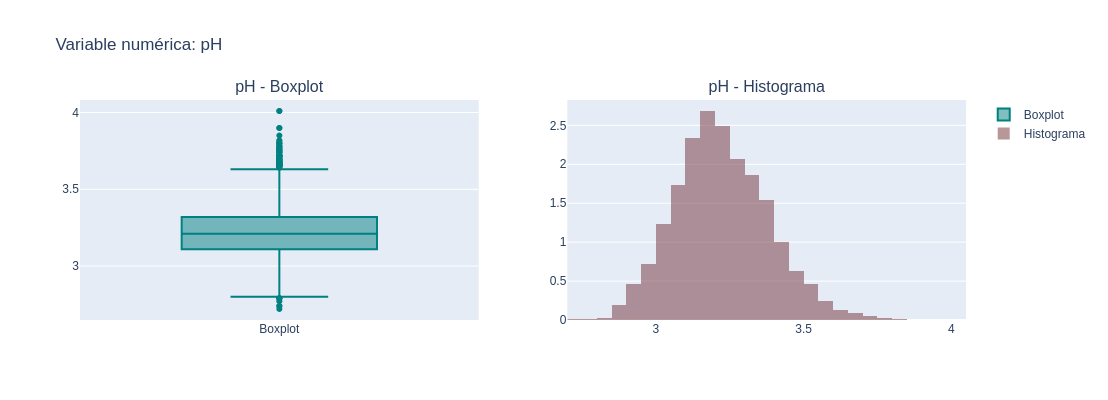

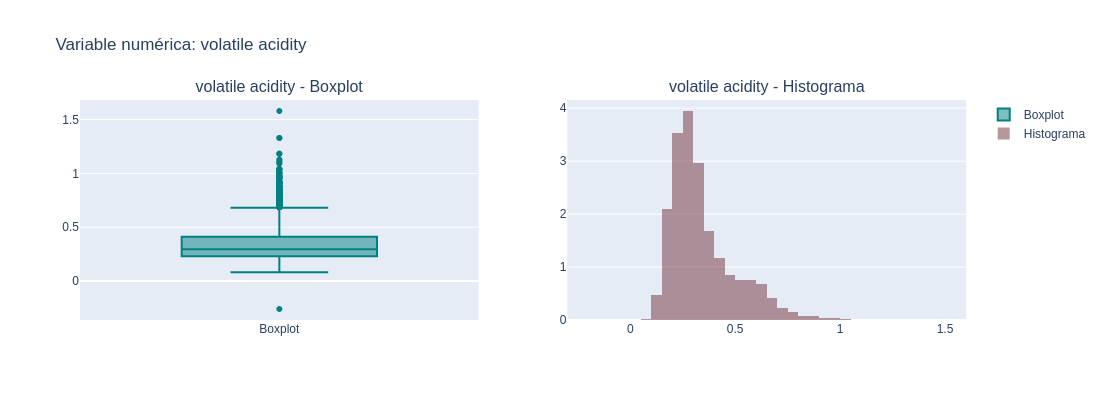

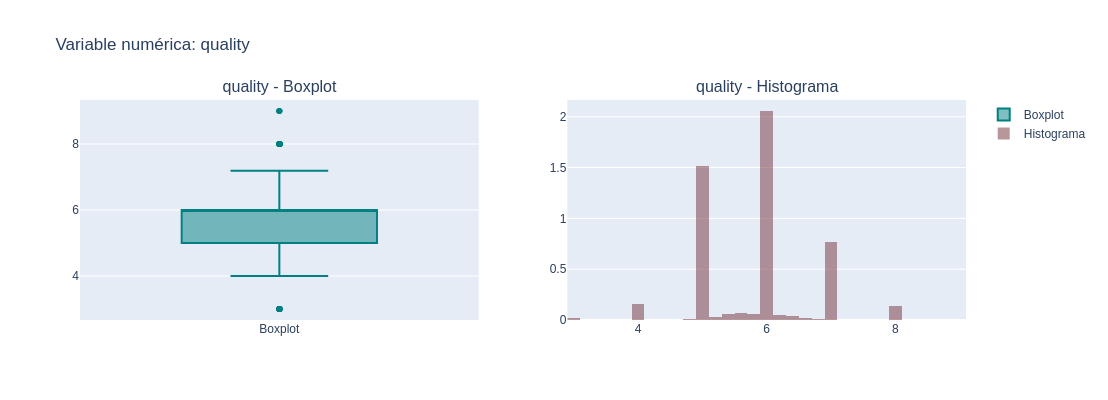

In [31]:
analisis.plot_num()

### Valores Atípicos

In [32]:
df_val_atipicos[['Variable', 'Unidad', 'Límite Inf', 'Límite Sup', 'Valores Atípicos']]

,Variable,Unidad,Límite Inf,Límite Sup,Valores Atípicos
0,fixed acidity,g/dm³,4.000,15.000,5
1,volatile acidity,g/dm³,0.120,1.100,31
2,citric acid,g/dm³,0.000,1.000,1
3,residual sugar,g/dm³,0.600,65.000,1
4,chlorides,g/dm³,0.009,0.346,18
5,free sulfur dioxide,mg/dm³,1.000,72.000,92
6,total sulfur dioxide,mg/dm³,6.000,440.000,0
7,density,g/cm³,0.990,1.004,348
8,pH,-,2.900,3.900,79
9,sulphates,g/dm³,0.220,1.080,35


**Variable Chlorides**

Aunque en el gráfico de boxplot de la variable chlorides pareciera que hay muchos puntos atípicos, si tomamos en cuenta el rango normal de la variable (valores entre 0.009 y 0.346), en realidad solo se identifican 18 valores fuera de este rango, lo cual es un número reducido en comparación con lo que sugiere el gráfico.

In [33]:
print("Valores atípicos en la variable chlorides:", imputed_df[(imputed_df['chlorides'] < 0.009) | (imputed_df['chlorides'] > 0.346)].shape[0])

Valores atípicos en la variable chlorides: 18


**Variable Density**

In [34]:
print("Valores atípicos en la variable density:", imputed_df[(imputed_df['density'] < 0.99) | (imputed_df['density'] > 1.004)].shape[0])

Valores atípicos en la variable density: 348


In [35]:
percentiles = [0, 1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100]

valores = np.percentile(imputed_df['density'], percentiles)

percentiles_df = pd.DataFrame(data = [valores], columns = percentiles)

display(percentiles_df)

,0,1,5,10,20,30,40,50,60,70,80,90,95,99,100
0,0.98711,0.98892,0.9899,0.99067,0.9918,0.9928,0.9938,0.99489,0.99568,0.99655,0.9974,0.9984,0.999392,1.0006,1.03898


In [36]:
percentiles = np.arange(5, 10.5, 0.5)  # incluimos 10

valores = np.percentile(imputed_df['density'], percentiles)

percentiles_df = pd.DataFrame(data = [valores], columns = percentiles)

display(percentiles_df)

,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0
0,0.9899,0.99,0.990078,0.990182,0.99022,0.99031,0.9904,0.990472,0.99058,0.9906,0.99067


Vemos que un 5.5% de la muestra se acumula por debajo del valor mínimo esperado, 345 de los 348 valores atípicos observados anteriormente, el resto son valores mayores a 1.004.

In [37]:
imputed_df[imputed_df['density'] < np.percentile(imputed_df['density'], 5.5)].shape[0]

345

Density es la variable con más valores atípicos, sin embargo, tomando en cuenta que los valores por debajo del valor mínimo esperado se encuentran cerca de éste, entonces más adelante podemos considerar si los mantenemos como parte de la muestra.

**Detección de outliers**

In [38]:
#Detectar
def detect_outliers_iforest(df, n_estimators=100, contamination=0.01, random_state=1989):
    model = IForest(n_estimators=n_estimators, contamination=contamination, random_state=random_state)
    model.fit(df.values)
    preds = model.predict(df.values)
    return df[preds == 1]

In [39]:
df_outliers = detect_outliers_iforest(imputed_df[var_num])

In [40]:
N = imputed_df.shape[0] # Filas del dataframe original

In [41]:
n_outliers = df_outliers.shape[0] # Outliers

In [42]:
prop = n_outliers / N
print(f"Proporción de valores atípicos: {prop:.6%}")

Proporción de valores atípicos: 1.000462%


In [43]:
df_val_atipicos[['Variable', 'Unidad', 'Límite Inf', 'Límite Sup', 'Valores Atípicos']]

,Variable,Unidad,Límite Inf,Límite Sup,Valores Atípicos
0,fixed acidity,g/dm³,4.000,15.000,5
1,volatile acidity,g/dm³,0.120,1.100,31
2,citric acid,g/dm³,0.000,1.000,1
3,residual sugar,g/dm³,0.600,65.000,1
4,chlorides,g/dm³,0.009,0.346,18
5,free sulfur dioxide,mg/dm³,1.000,72.000,92
6,total sulfur dioxide,mg/dm³,6.000,440.000,0
7,density,g/cm³,0.990,1.004,348
8,pH,-,2.900,3.900,79
9,sulphates,g/dm³,0.220,1.080,35


In [44]:
df_outliers.describe().loc[['min', '25%', '50%', '75%', 'max'],:]

,residual sugar,alcohol,citric acid,chlorides,fixed acidity,total sulfur dioxide,sulphates,density,free sulfur dioxide,pH,volatile acidity,quality
min,-0.481195,8.4,-0.28288,0.013,4.2,-19.857417,0.340000,0.98722,3.0,2.74,0.170000,3.0
25%,1.800000,9.2,0.15000,0.072,6.5,19.000000,0.679885,0.99580,6.0,3.00,0.412244,5.0
50%,2.200000,9.9,0.50000,0.097,8.5,46.000000,0.810000,0.99740,12.0,3.07,0.540000,5.0
75%,4.800000,12.0,0.67000,0.301,11.5,71.000000,1.060000,0.99990,19.0,3.32,0.660000,6.0
max,17.550000,14.9,1.00000,0.611,15.9,233.000000,2.000000,1.00369,93.0,4.01,1.580000,8.0


De la tabla anterior vemos que la mayoría de los valores se encuentran en el rango normal de cada variable, los que si están fuera de lo normal son los valores negativos de las variables residual sugar, total sulfur dioxide, citric acid. Además como ya veíamos los valores arriba de 0.346 de la variable chlorides.

In [45]:
new_n_outliers = df_outliers[(df_outliers['chlorides'] > 0.346) | (df_outliers['citric acid'] < 0) | (df_outliers['residual sugar'] < 0.6) | (df_outliers['total sulfur dioxide'] < 6) | (df_outliers['density'] < 0.99)].shape[0]

In [46]:
#Eliminamos esos valores (0.4% de la muestra)
df_clean = imputed_df.drop(df_outliers.index)

In [47]:
# Quitando valores atípicos que salen por el método Isolation Forest
print("Dimensión anterior:", N, ", nueva dimensión:", df_clean.shape[0])

Dimensión anterior: 6497 , nueva dimensión: 6432


In [48]:
# Si quitáramos valores atípicos de la variable density y de los valores atípicos que vemos con el método Isolation Forest
print("Dimensión anterior:", N, ", nueva dimensión:", N-imputed_df[(imputed_df['chlorides'] > 0.346) | (imputed_df['citric acid'] < 0) | (imputed_df['residual sugar'] < 0.6) | (imputed_df['total sulfur dioxide'] < 6) | (imputed_df['density'] < 0.99)].shape[0])

Dimensión anterior: 6497 , nueva dimensión: 6113


**Variable Quality**

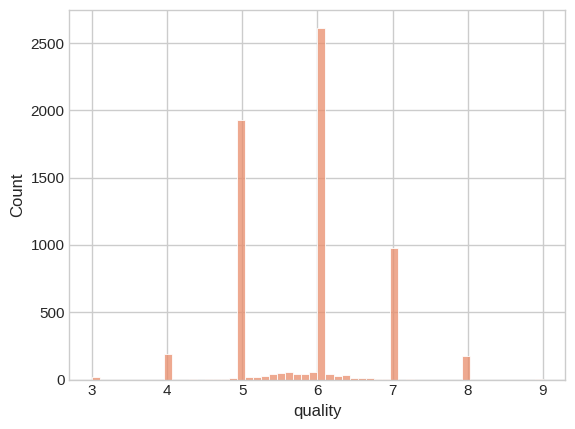

In [49]:
sns.histplot(df_clean['quality'])
plt.show()

In [50]:
decimales_num = (df_clean['quality'].astype(str).str.split('.', expand=True)[1].astype(int) != 0).sum()

print('Valores con decimales:', decimales_num)
print('Proporción con decimales:', '{0:.2%}'.format(decimales_num/N))

Valores con decimales: 586
Proporción con decimales: 9.02%


In [51]:
df_clean['quality'] = df_clean['quality'].astype(int)

In [52]:
df_clean['quality'].value_counts(normalize=True).sort_index().apply(lambda x: '{0:.2%}'.format(x))

quality
3     0.34%
4     3.36%
5    35.42%
6    42.96%
7    15.19%
8     2.67%
9     0.06%
Name: proportion, dtype: object

Los valores decimales de **quality** fueron ajustados a enteros con el fin de mantener consistencia con la definición original de la variable y facilitar el análisis estadístico.

## 3.- Describe estadísticamente cada variable del conjunto de datos y anota las observaciones relevantes con respecto a la tendencia central y dispersión.

In [53]:
df_clean.describe().loc[['count','mean','std','min','25%','50%','75%','max'],:].T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6432.0,7.197885,1.227256,3.800000,6.4000,7.000000,7.70000,15.00000
volatile acidity,6432.0,0.337778,0.155747,-0.261265,0.2300,0.290221,0.40000,1.33000
citric acid,6432.0,0.317302,0.138762,0.000000,0.2500,0.310000,0.39000,1.66000
residual sugar,6432.0,5.452255,4.751851,-3.297837,1.8000,3.100000,8.10000,65.80000
chlorides,6432.0,0.054715,0.028541,0.009000,0.0380,0.047000,0.06400,0.40100
free sulfur dioxide,6432.0,30.665088,17.597988,-0.813248,17.0000,29.000000,41.00000,289.00000
total sulfur dioxide,6432.0,115.940528,55.295073,-2.687222,79.0000,119.000000,155.00000,440.00000
density,6432.0,0.994668,0.002978,0.987110,0.9923,0.994835,0.99692,1.03898
pH,6432.0,3.218681,0.157997,2.720000,3.1100,3.210000,3.32000,3.90000
sulphates,6432.0,0.528178,0.138621,0.220000,0.4400,0.502864,0.60000,1.98000


* **El 76% de la muestra corresponden a vinos blancos.**

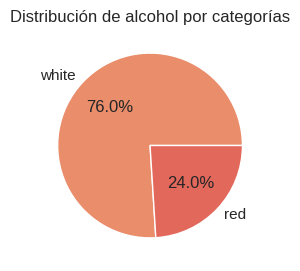

In [54]:
df_clean['type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(3,3),
    #colors=sns.color_palette("Set2"),
    title="Distribución de alcohol por categorías"
)
plt.ylabel("")  # quita la etiqueta del eje y
plt.show()

* **El porcentaje de alcohol de los vinos se concentra en 10% y el 15% (media del 10%).**

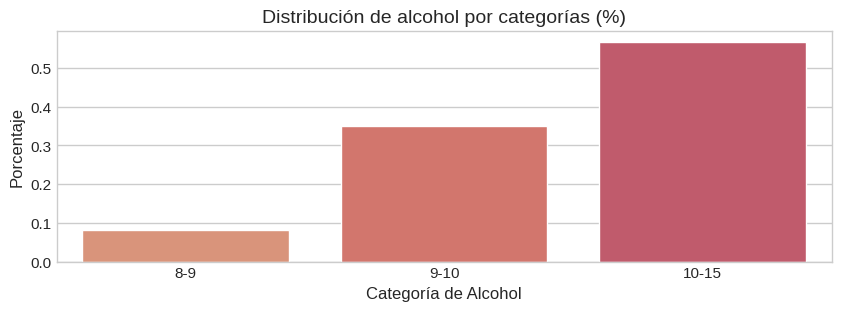

In [55]:
# Definir los bordes de los intervalos
bins = [8, 9, 10, 15]
labels = ['8-9', '9-10', '10-15']

# Crear variable categórica ordenada
df_clean['alcohol_cat'] = pd.cut(
    df_clean['alcohol'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True,
    ordered=True
)

# Calculamos porcentajes
counts = df_clean['alcohol_cat'].value_counts(normalize=True).reset_index()
counts.columns = ['categoria', 'porcentaje']

plt.figure(figsize=(10,3))
sns.barplot(
    x="categoria", 
    y="porcentaje", 
    hue="categoria",       # aquí usamos hue
    data=counts, 
    #palette="Set2", 
    legend=False           # quitamos la leyenda duplicada
)

plt.title("Distribución de alcohol por categorías (%)", fontsize=14)
plt.xlabel("Categoría de Alcohol")
plt.ylabel("Porcentaje")
plt.show()

* **La mediana del pH se asimila con la media (3.22) y tiene una distribución casi simétrica. El valor de la media bajo hace sentido con los vinos, ya que tienen pH bajos (baja acidez).**

a) Media: 3.2187 
b) Desviación Estándar: 0.1580 
c) Mediana: 3.2100 



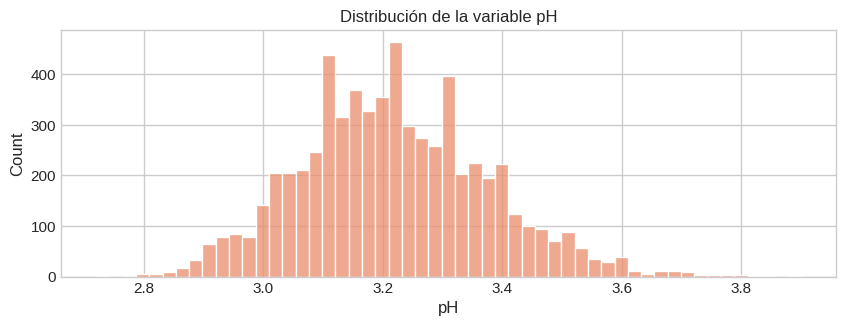

In [56]:
pH = df_clean['pH']

print('a) Media:', '{0:.4f}'.format(pH.mean()), 
      '\n'+'b) Desviación Estándar:', '{0:.4f}'.format(pH.std()),
      '\n'+'c) Mediana:', '{0:.4f}'.format(pH.quantile(0.5)), '\n')

plt.figure(figsize=(10,3.2))
sns.histplot(pH)
plt.title('Distribución de la variable pH')
plt.show()

* **La calidad de los vinos se concentra en el rango de 5 a 7, lo cual hace sentido con la media de 5.7.**

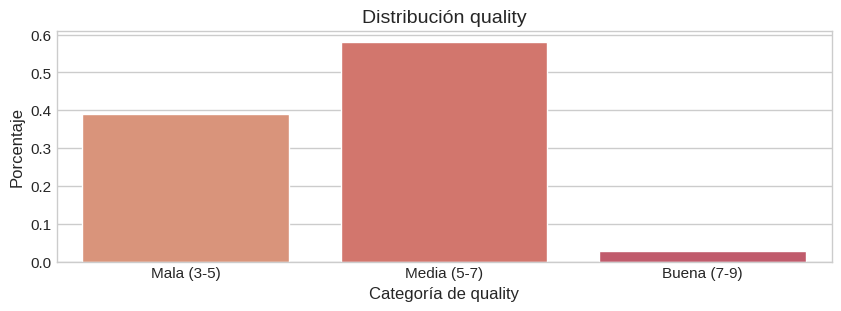

In [57]:
# Definir los bordes de los intervalos
bins = [3, 5, 7, 9]
labels = ['Mala (3-5)', 'Media (5-7)', 'Buena (7-9)']

# Crear variable categórica ordenada
df_clean['quality_cat'] = pd.cut(
    df_clean['quality'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True,
    ordered=True
)

# Calculamos porcentajes
counts = df_clean['quality_cat'].value_counts(normalize=True).reset_index()
counts.columns = ['categoria', 'porcentaje']

plt.figure(figsize=(10,3))
sns.barplot(
    x="categoria", 
    y="porcentaje", 
    hue="categoria",       # aquí usamos hue
    data=counts, 
    #palette="Set2", 
    legend=False           # quitamos la leyenda duplicada
)

plt.title("Distribución quality", fontsize=14)
plt.xlabel("Categoría de quality")
plt.ylabel("Porcentaje")
plt.show()

## 4.- Realiza una comparativa de variables con respecto al tipo de vinos de tu interés. Por ejemplo, ¿Los vinos tintos tienen más acidez fija que los blancos?

### ¿La relación entre el azúcar residual y la densidad es diferente entre vinos tintos y blancos?

En los vinos blancos se observa una mayor cantidad de azúcar residual, lo que incrementa su densidad y favorece su perfil como vinos más dulces. En contraste, los vinos tintos suelen presentar un contenido mucho menor de azúcar residual, lo que los caracteriza como vinos más secos.

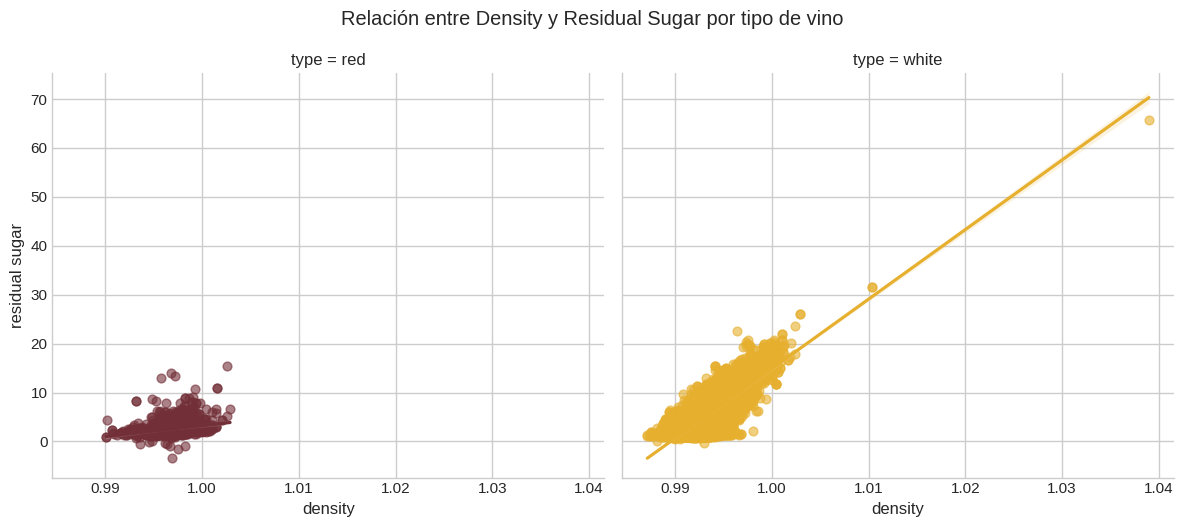

In [58]:
palette = {"red": "#722F37", "white": "#E6AF2E"}  # burdeos y dorado

sns.lmplot(
    data=df_clean,
    x="density", y="residual sugar",
    col="type", hue="type",             # <-- clave
    palette=palette, legend=False,
    height=5, aspect=1.2,
    scatter_kws={"alpha":0.6, "s":40},
)
plt.suptitle("Relación entre Density y Residual Sugar por tipo de vino", y=1.05)
plt.show()


### ¿Los vinos tintos tienen más acidez fija que los blancos?

Los resultados muestran que los vinos tintos presentan en promedio una mayor acidez fija que los blancos, lo que se traduce en sabores más intensos, estructura y mayor potencial de guarda. En contraste, los vinos blancos, al tener una acidez fija más baja, tienden a ser más frescos, ligeros y fáciles de beber.

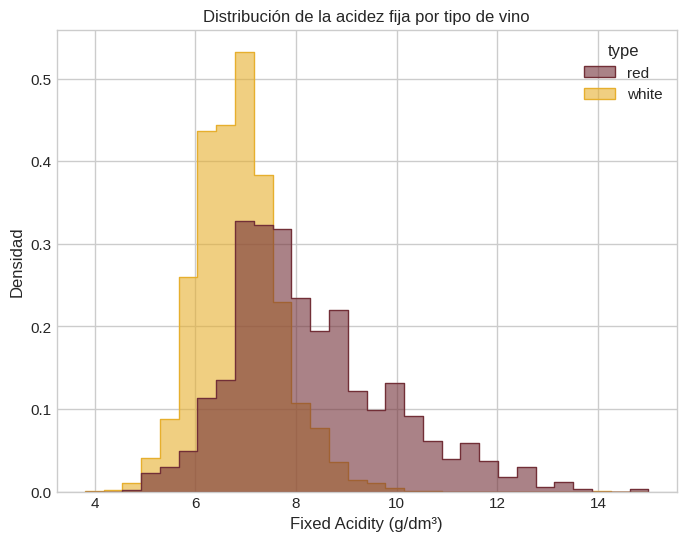

In [59]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=df_clean,
    x="fixed acidity",     # o "volatile acidity"
    hue="type",            # separa por tipo de vino
    palette={"red": "#722F37", "white": "#E6AF2E"},
    element="step",        # estilo de línea, más claro para comparar
    stat="density",        # normaliza para comparar distribuciones
    common_norm=False,     # cada grupo con su propia escala
    bins=30,               # número de intervalos
    alpha=0.6
)

plt.title("Distribución de la acidez fija por tipo de vino")
plt.xlabel("Fixed Acidity (g/dm³)")
plt.ylabel("Densidad")
plt.show()

## P5.- Realiza un análisis de las variables con respecto a la calidad del vino. ¿Los vinos de mejor calidad tienen más alcohol, más acidez fija, menor azúcar residual, etc.? (Hint. Puedes cortar y agrupar la calidad del vino en buena o mala o en mala, media, buena si crees que te ayudaría al análisis).

In [60]:
df_clean["quality_cat_word"] = df_clean["quality_cat"].str.split(' ', expand=True)[0] # categoría

df_clean["quality_cat_word"] = pd.Categorical(
    df_clean["quality_cat_word"],
    categories=["Mala", "Media", "Buena"],
    ordered=True
)

# 'count' en columna quality y en las demás los promedios
calidad = df_clean.groupby(["type", "quality_cat_word"], observed=True).agg(
    {col: "mean" for col in var_num} | {"quality": ["count", "mean"]}
)

# Renombrar columnas
calidad.columns = [f"{c[0]}_{c[1]}" if c[1] != "" else c[0] for c in calidad.columns]

calidad = calidad.loc[:, ['quality_count','quality_mean'] + list(set(calidad.columns)-set(['quality_count','quality_mean']))]

display(calidad)

quality_count  quality_mean  sulphates_mean  \
type  quality_cat_word                                                
red   Mala                        759      4.905138        0.610624   
      Media                       773      6.218629        0.689872   
      Buena                        12      8.000000        0.782036   
white Mala                       1757      4.892999        0.481221   
      Media                      2967      6.272329        0.494382   
      Buena                       164      8.024390        0.480381   

                        total sulfur dioxide_mean   pH_mean  \
type  quality_cat_word                                        
red   Mala                              54.059367  3.315298   
      Media                             38.938495  3.314269   
      Buena                             26.364308  3.286669   
white Mala                             148.206549  3.172978   
      Media                            132.487787  3.195600   
      Buena                            126.783039  3.223220   

                        fixed acidity_mean  free sulfur dioxide_mean  \
type  quality_cat_word                                                 
red   Mala                        8.106596                 16.553452   
      Media                       8.469396                 15.404405   
      Buena                       8.203763                 14.750000   
white Mala                        6.964783                 35.440551   
      Media                       6.799338                 35.133968   
      Buena                       6.633184                 37.058756   

                        volatile acidity_mean  alcohol_mean  \
type  quality_cat_word                                        
red   Mala                           0.582049      9.935129   
      Media                          0.473979     10.865275   
      Buena                          0.391306     12.069157   
white Mala                           0.305705      9.845229   
      Media                          0.262276     10.852952   
      Buena                          0.270938     11.642531   

                        residual sugar_mean  citric acid_mean  density_mean  \
type  quality_cat_word                                                        
red   Mala                         2.497604          0.230115      0.997030   
      Media                        2.506404          0.297327      0.996430   
      Buena                        2.550000          0.374896      0.994893   
white Mala                         7.042288          0.334097      0.995162   
      Media                        6.032496          0.334050      0.993445   
      Buena                        5.691817          0.327813      0.992260   

                        chlorides_mean  
type  quality_cat_word                  
red   Mala                    0.086229  
      Media                   0.080860  
      Buena                   0.070417  
white Mala                    0.050675  
      Media                   0.043078  
      Buena                   0.038317

In [61]:
calidad_copy = calidad.copy()
calidad_copy = calidad_copy.loc[:, list(set(calidad.columns)-set(['quality_count']))].map(lambda x: f"{x:.4f}")
calidad_copy.to_csv('~/Downloads/wine_agg_table.csv')

In [69]:
from pandas.api.types import CategoricalDtype

class analyze_by_cat:
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    def plot_box_hist_by_cat(self, var, category_col="quality_cat_word", hue_col="type"):
        # paleta “vinícola”
        palette = {"red": "#722F37", "white": "#E6AF2E"}  # burdeos y dorado
    
        # respetar el orden de las categorías si existe
        if isinstance(self.df[category_col].dtype, CategoricalDtype):
            cats = list(self.df[category_col].cat.categories)
        else:
            cats = list(pd.unique(self.df[category_col]))
    
        fig = make_subplots(
            rows=1, cols=2,
            column_widths=[0.55, 0.45],
            subplot_titles=(f"{var} — Boxplot por {category_col}", f"{var} — Histograma por {hue_col}")
        )
    
        # --------- Columna 1: BOX PLOT (x = categoría, color = tipo) ----------
        for t, color in palette.items():
            df_t = self.df[self.df[hue_col] == t]
            fig.add_trace(
                go.Box(
                    x=pd.Categorical(df_t[category_col], categories=cats, ordered=True),
                    y=df_t[var],
                    name=t,
                    marker_color=color,
                    boxmean='sd',
                    legendgroup=t,
                    showlegend=True  # mostramos leyenda aquí
                ),
                row=1, col=1
            )
    
        # --------- Columna 2: HISTOGRAMAS superpuestos (por tipo) ------------
        for t, color in palette.items():
            df_t = self.df[self.df[hue_col] == t]
            fig.add_trace(
                go.Histogram(
                    x=df_t[var],
                    name=t,
                    marker_color=color,
                    opacity=0.55,
                    nbinsx=40,
                    histnorm='probability density',
                    legendgroup=t,
                    showlegend=False  # ya aparece en col 1
                ),
                row=1, col=2
            )
    
        # layout
        fig.update_layout(
            title_text=f"Variable numérica: {var}",
            height=420, width=900,
            boxmode='group',          # agrupa cajas por categoría
            barmode='overlay',        # superpone histogramas
            margin=dict(t=60)
        )
        fig.update_xaxes(title_text=category_col, row=1, col=1)
        fig.update_yaxes(title_text=var,           row=1, col=1)
        fig.update_xaxes(title_text=var,           row=1, col=2)
        fig.update_yaxes(title_text="densidad",    row=1, col=2)
    
    
    def plot_box_hist_by_cat(self, var, category_col="quality_cat_word", hue_col="type"):
        # paleta “vinícola”
        palette = {"red": "#722F37", "white": "#E6AF2E"}  # burdeos y dorado
    
        # respetar el orden de las categorías si existe
        if isinstance(self.df[category_col].dtype, CategoricalDtype):
            cats = list(self.df[category_col].cat.categories)
        else:
            cats = list(pd.unique(self.df[category_col]))
    
        fig = make_subplots(
            rows=1, cols=2,
            column_widths=[0.55, 0.45],
            subplot_titles=(f"{var} — Boxplot por {category_col}", f"{var} — Histograma por {hue_col}")
        )
    
        # --------- Columna 1: BOX PLOT (x = categoría, color = tipo) ----------
        for t, color in palette.items():
            df_t = self.df[self.df[hue_col] == t]
            fig.add_trace(
                go.Box(
                    x=pd.Categorical(df_t[category_col], categories=cats, ordered=True),
                    y=df_t[var],
                    name=t,
                    marker_color=color,
                    boxmean='sd',
                    legendgroup=t,
                    showlegend=True  # mostramos leyenda aquí
                ),
                row=1, col=1
            )
    
        # --------- Columna 2: HISTOGRAMAS superpuestos (por tipo) ------------
        for t, color in palette.items():
            df_t = self.df[self.df[hue_col] == t]
            fig.add_trace(
                go.Histogram(
                    x=df_t[var],
                    name=t,
                    marker_color=color,
                    opacity=0.55,
                    nbinsx=40,
                    histnorm='probability density',
                    legendgroup=t,
                    showlegend=False  # ya aparece en col 1
                ),
                row=1, col=2
            )
    
        # layout
        fig.update_layout(
            title_text=f"Variable numérica: {var}",
            height=420, width=900,
            boxmode='group',          # agrupa cajas por categoría
            barmode='overlay',        # superpone histogramas
            margin=dict(t=60)
        )
        fig.update_xaxes(title_text=category_col, row=1, col=1)
        fig.update_yaxes(title_text=var,           row=1, col=1)
        fig.update_xaxes(title_text=var,           row=1, col=2)
        fig.update_yaxes(title_text="densidad",    row=1, col=2)
    
        fig.show()

In [70]:
analisis = analyze_by_cat(df_clean, var_num, var_cat)

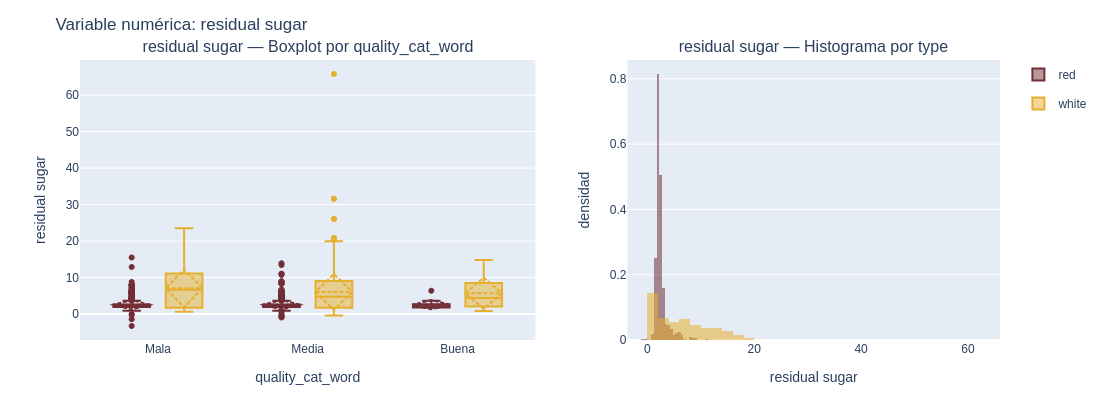

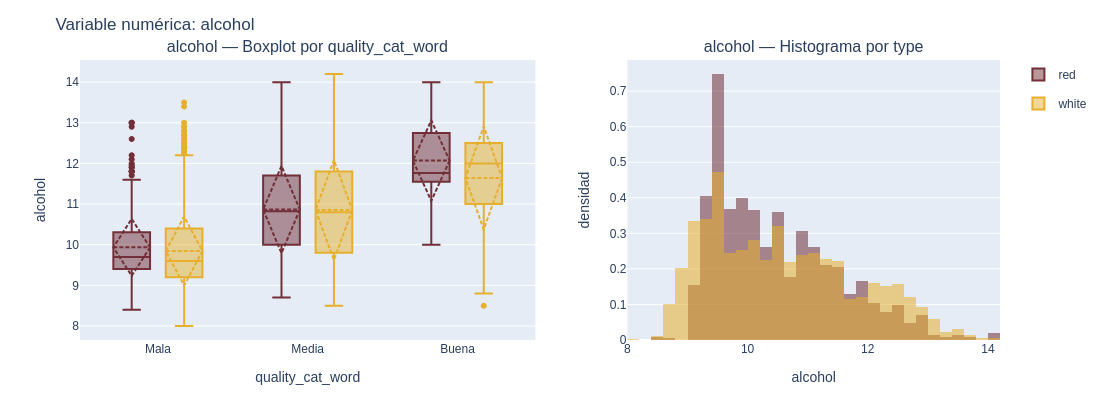

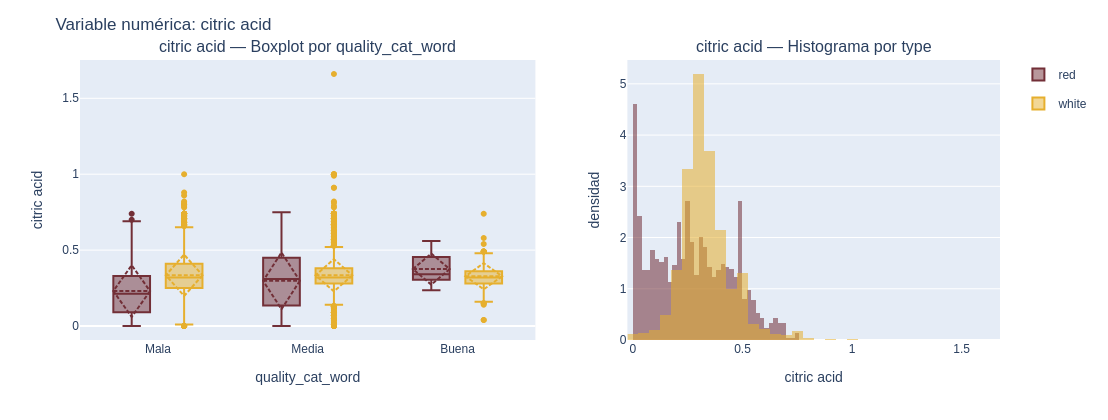

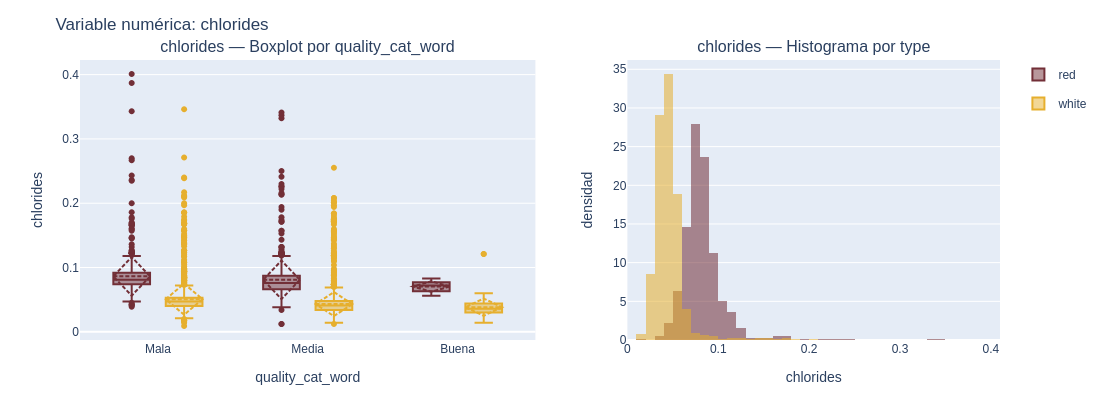

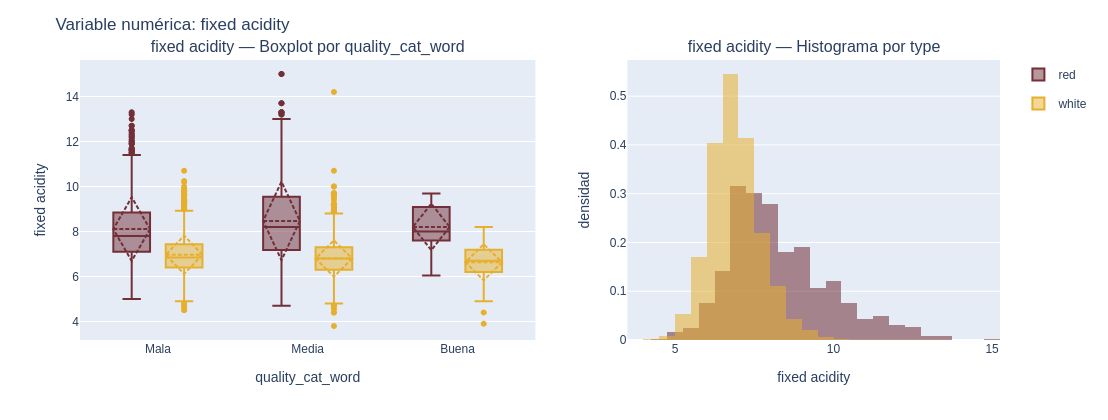

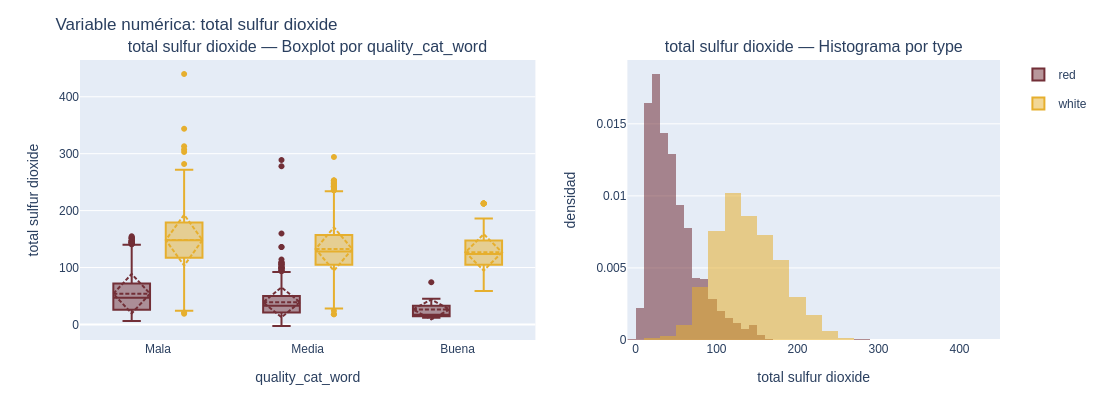

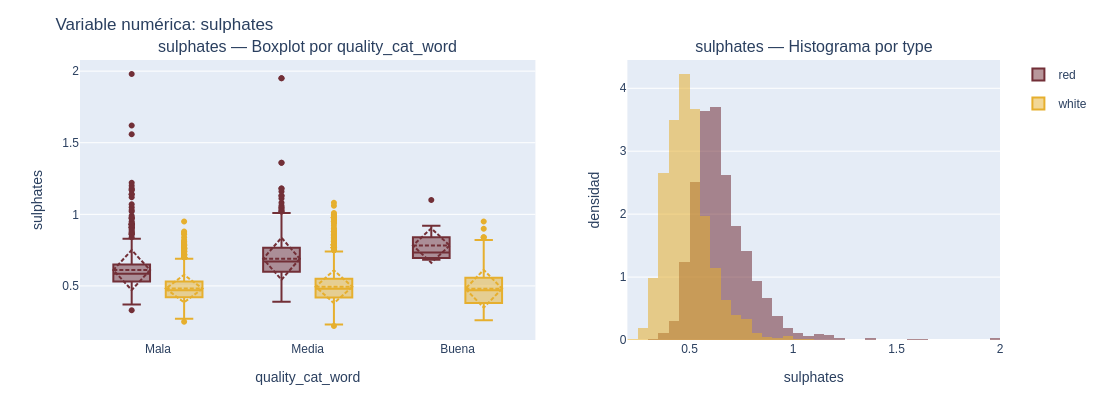

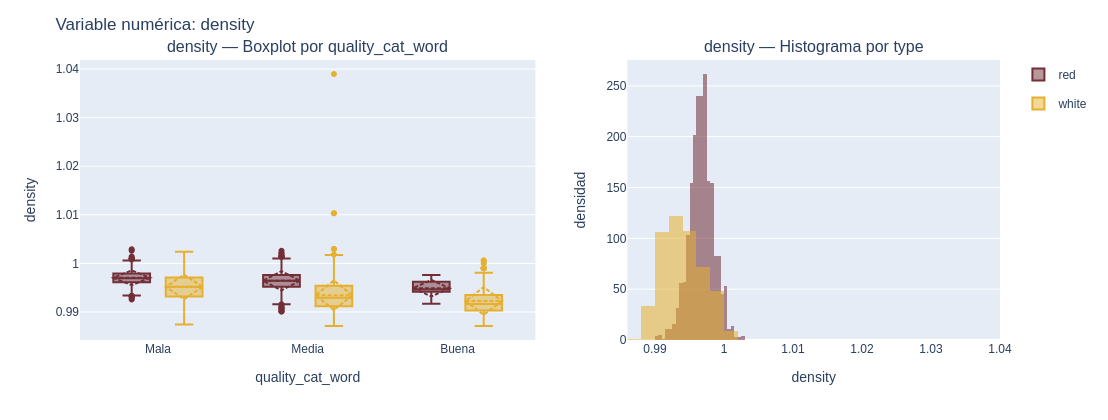

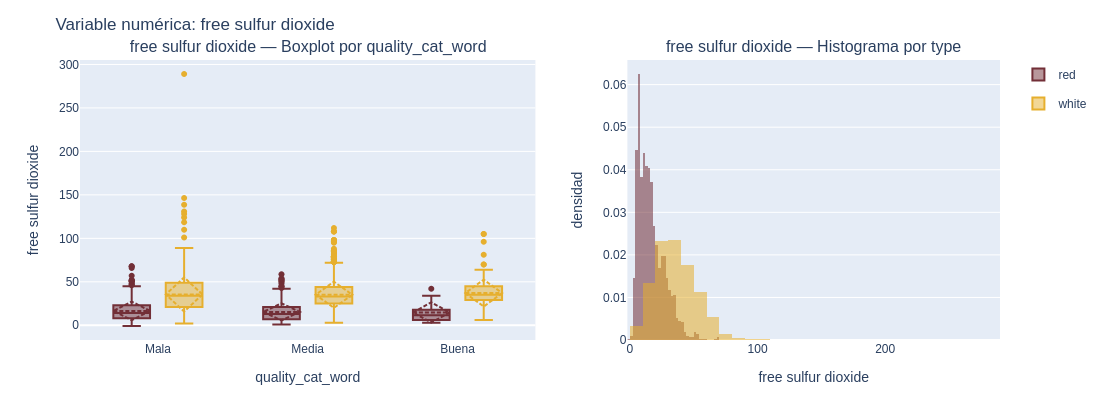

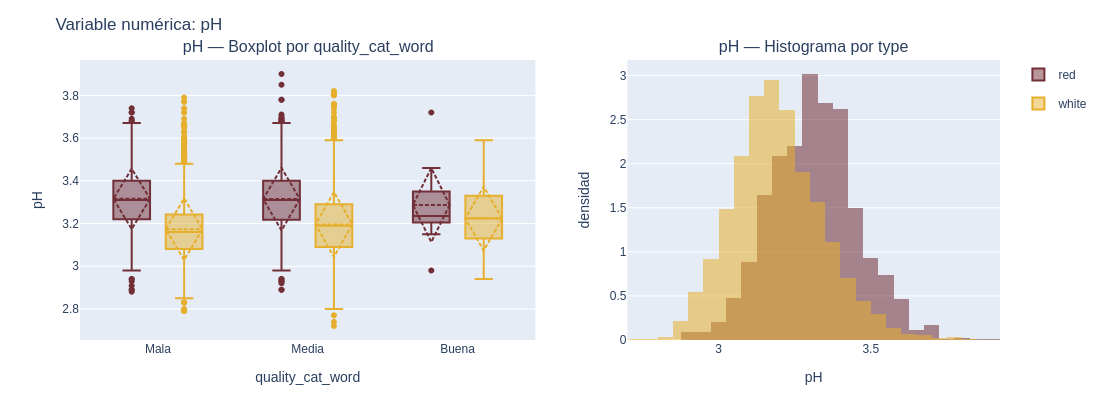

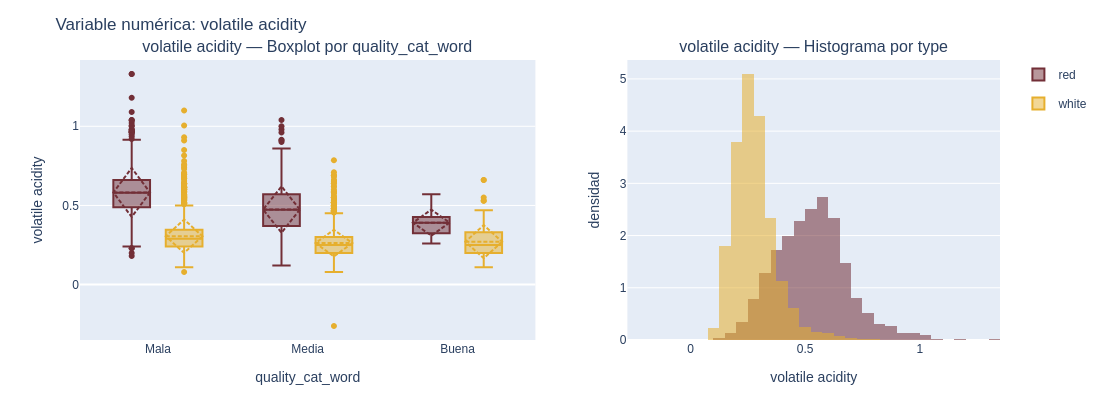

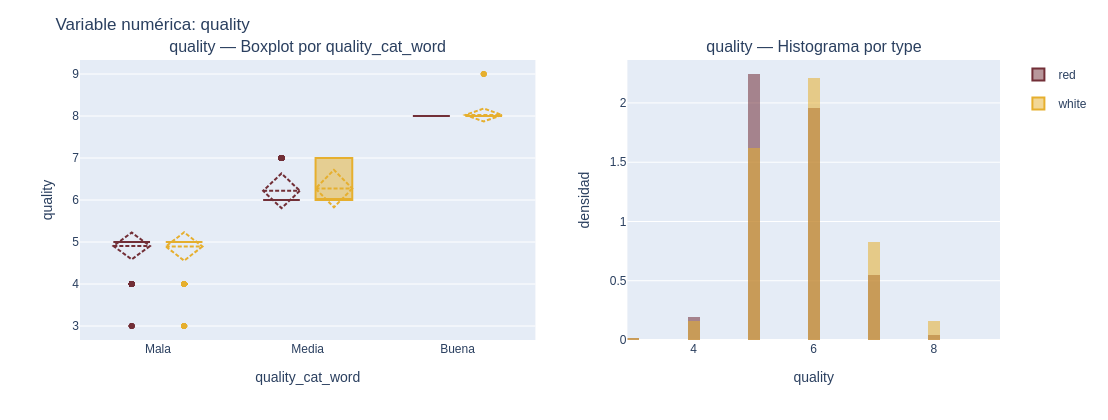

In [72]:
for v in analisis.num_vars:
    analisis.plot_box_hist_by_cat(v, "quality_cat_word", "type")

## P6.- Obtén la correlación de las variables y grafica su matriz. ¿Tiene sentido la correlación entre las variables? Explica el porqué sí o porqué no.

In [73]:
last_analisis = analyze(df_clean, var_num, var_cat)

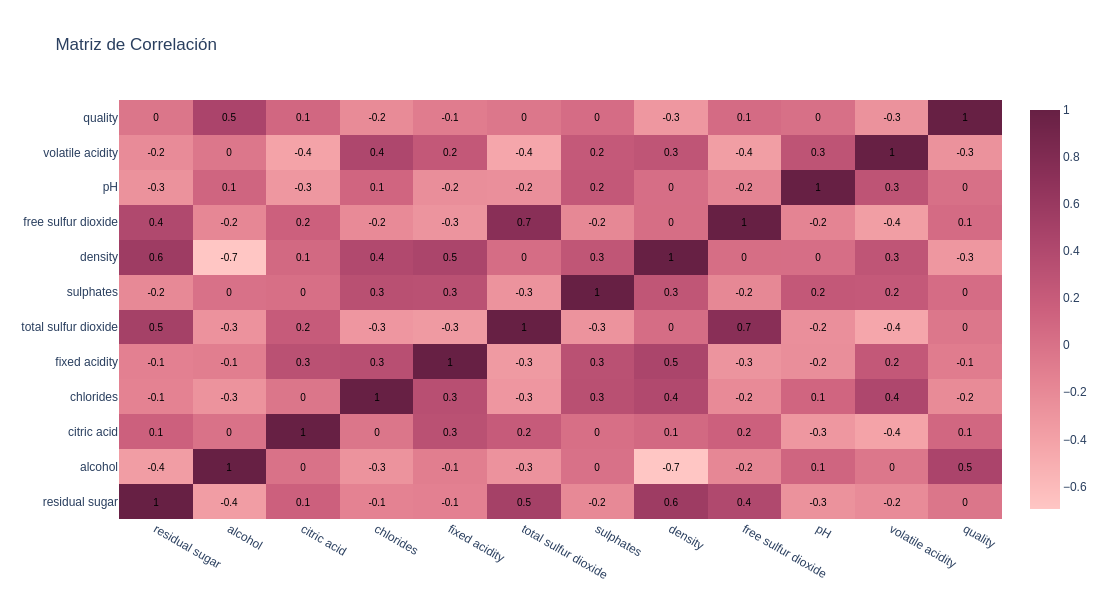

In [74]:
last_analisis.corr_matrix('burg')

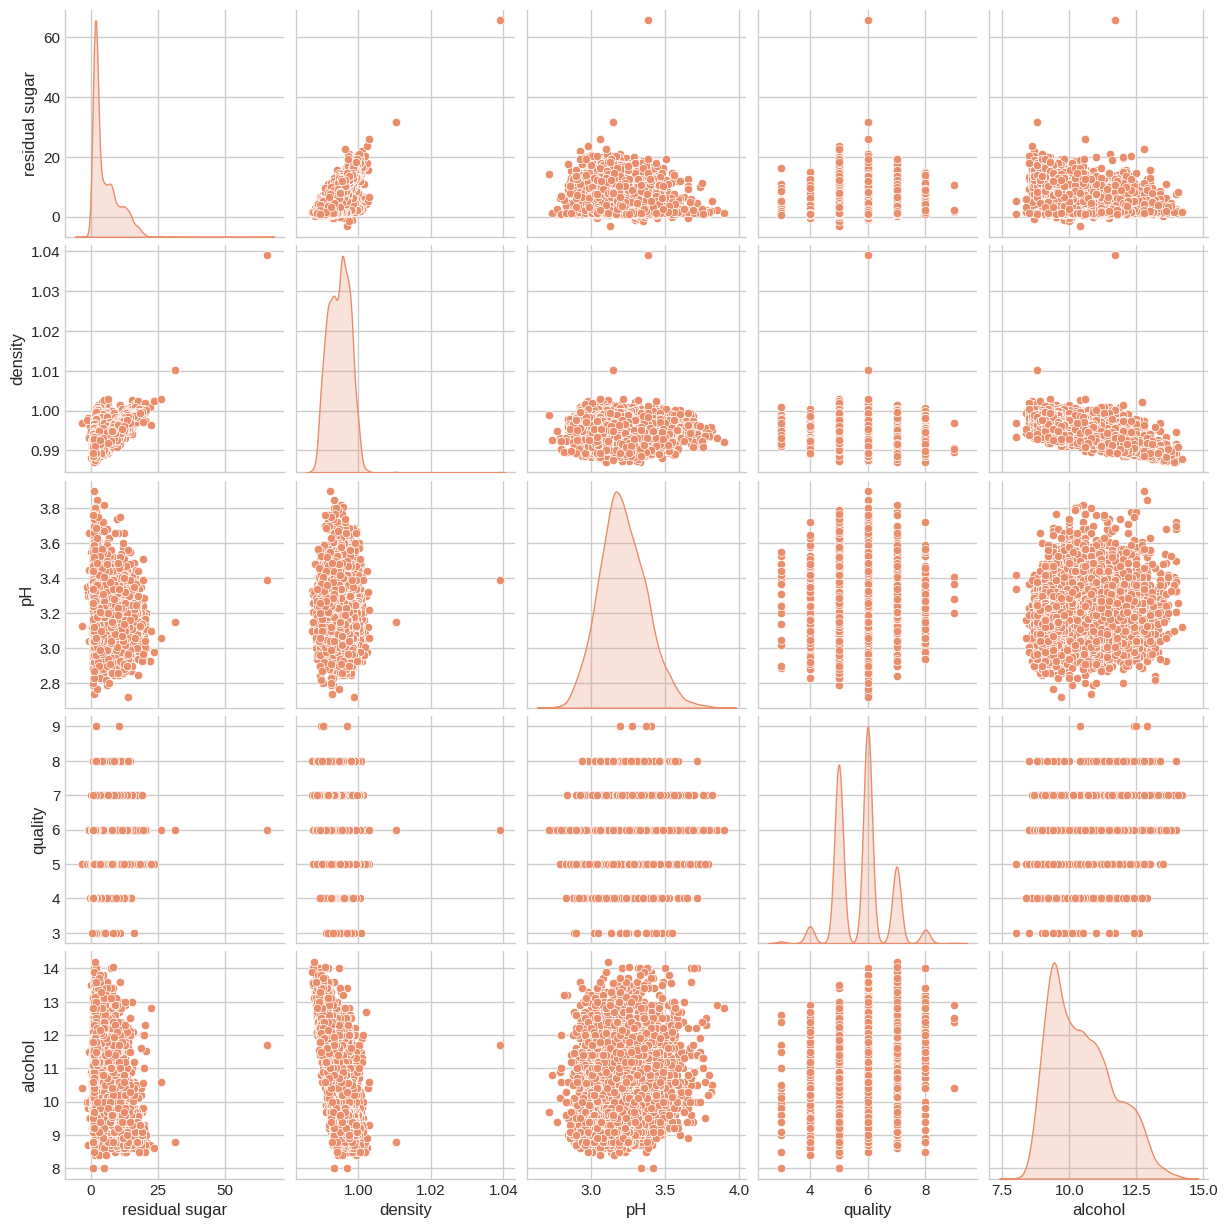

In [75]:
sns.pairplot(df_clean.loc[:,['residual sugar', 'density', 'pH', 'quality', 'alcohol']], diag_kind="kde")
plt.show()